Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [4]:
df = pd.read_csv('train.csv')

In [5]:
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

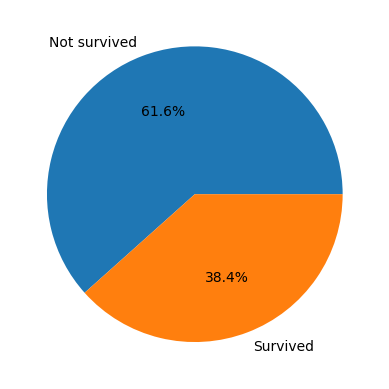

In [6]:
survive_rate = df['Survived'].value_counts()
labels = 'Not survived', 'Survived'
survive_rate_pie = plt.pie(survive_rate, labels=labels, autopct='%1.1f%%')

Вижили трохи більше ніж третина від загальної кількості.

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


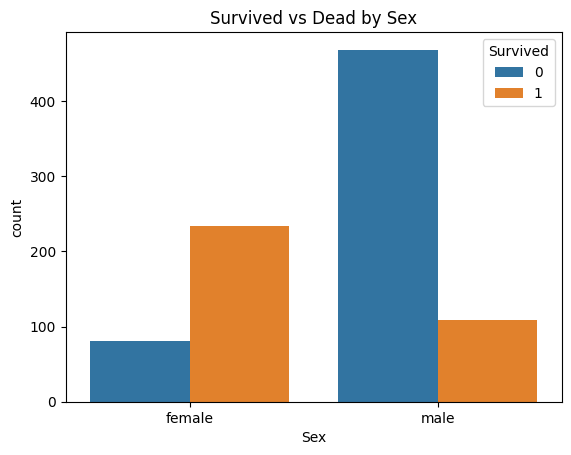

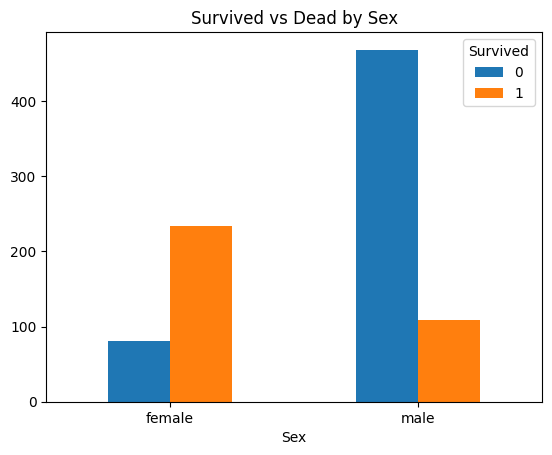

In [7]:
survive_rate_by_sex = df.groupby(['Sex', 'Survived'], as_index=False).size()
survive_rate_by_sex = survive_rate_by_sex.pivot(index='Sex', columns='Survived', values='size')
ax = survive_rate_by_sex.plot.bar()
ax.set_title('Survived vs Dead by Sex')
ax.tick_params(axis='x', labelrotation=0)

Жінки переважно вижили, в той час як чоловіки переважно загинули, при чому незважаючи на більшу кількість чоловіків, жінок вижило більше.

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

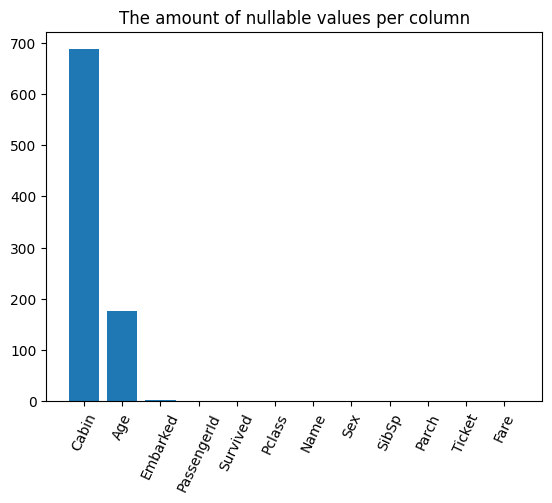

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'PassengerId'),
  Text(1, 0, 'Survived'),
  Text(2, 0, 'Pclass'),
  Text(3, 0, 'Name'),
  Text(4, 0, 'Sex'),
  Text(5, 0, 'Age'),
  Text(6, 0, 'SibSp'),
  Text(7, 0, 'Parch'),
  Text(8, 0, 'Ticket'),
  Text(9, 0, 'Fare'),
  Text(10, 0, 'Cabin'),
  Text(11, 0, 'Embarked')])

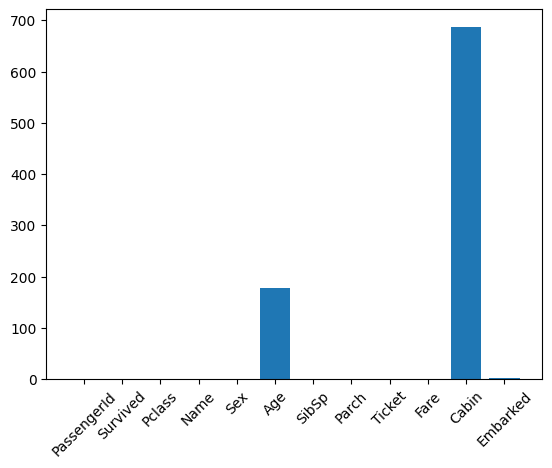

In [8]:
empty_vals = df.isna().sum()
plt.bar(df.columns, empty_vals)
plt.xticks(rotation=45)

Більшість колонок повністю відомі, окрім каюти і віку пасажирів. Також невідомі дані про посадку деяких пасажирів

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

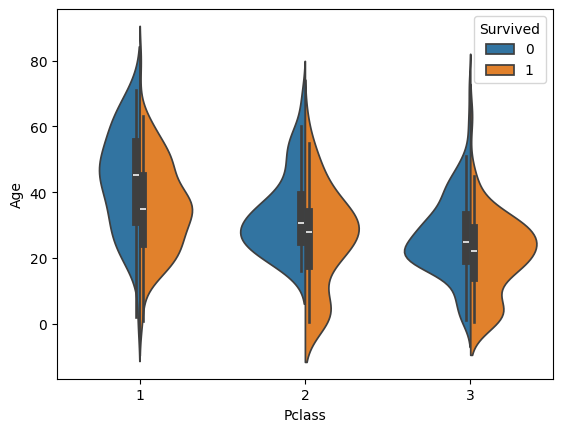

Text(0.5, 1.0, 'Correlation of survival with age and class')

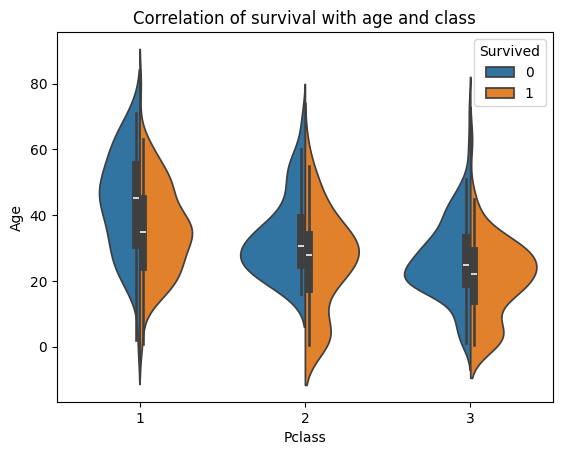

In [24]:
ax = sns.violinplot(df, x='Pclass', y='Age', hue='Survived', split=True)
ax.set_title('Correlation of survival with age and class')

Вік пасажирів 1 класу доволі рівномірно розподілений від 20 до 60 років і зі зростанням віку виживаємість падає. 2 клас переважно від 20 до 40, а кількісь загиблих значно більше за виживших. 3 клас має розподіл по віку схожий на 2 клас, але зсунутий на 5 років нижче, при цьому співвідношення по виживаємості прибилизно 1:1 з невеликою перевагою виживших.

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


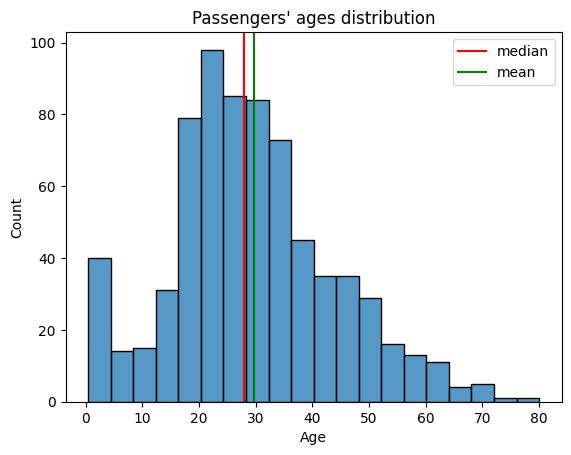

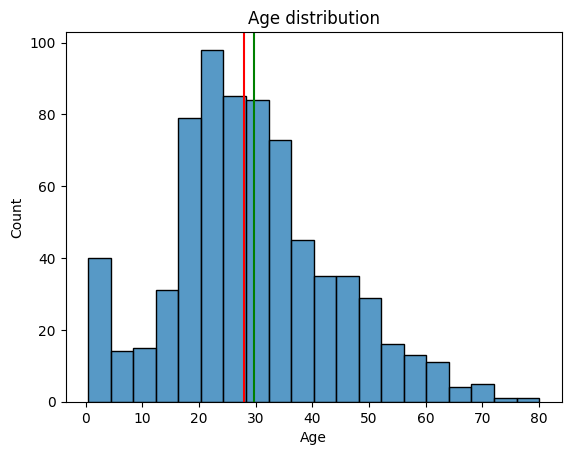

In [23]:
ax = sns.histplot(df, x='Age')
ax.set_title('Age distribution')
age_mean = df['Age'].mean()
age_median = df['Age'].median()
plt.axvline(age_mean, color='green')
plt.axvline(age_median, color='red')

Найбільше усього пасажирів були віком від 18 до 35 років, далі частота падає з віком. Також значну частину становили маленькі діти (до 5 років).

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

Знаючи що відсоток виживших серед жінок значно більше ніж серед чоловіків, чи наявна різниця у віковій структурі чоловіків і жінок на борту, яка б могла вплинути на це?

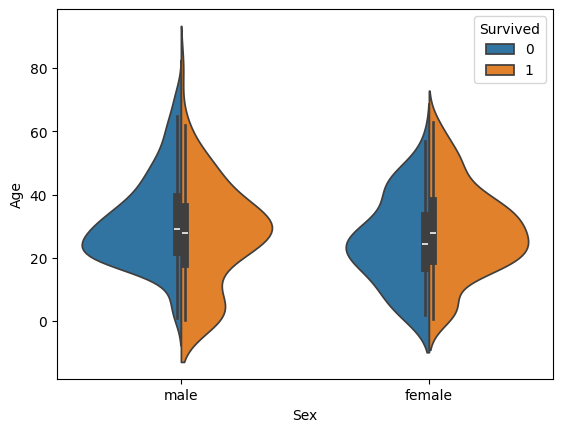

In [29]:
ax = sns.violinplot(df, x='Sex', y='Age', hue='Survived', split=True)

Помітна різниця у віковій структурі відсутня, проте видно що різницю у відсотках виживших створтла вікова категорія 20-40, в той час як інші більш рівномірні

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

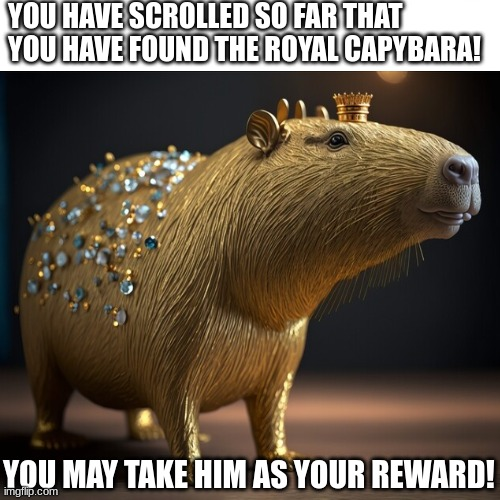